In [1]:
import sys; sys.path.append("..")
from openbabel import openbabel as ob
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from networkx.algorithms import isomorphism
from sqlalchemy.orm import Session
import os
from src import utils
# connect to database
from sqlalchemy import create_engine, text
from sqlalchemy.orm import sessionmaker
engine = create_engine("sqlite:///{}".format("../main.db"))
session = sessionmaker(bind=engine)()
all_sids = [x[0] for x in session.execute(text("SELECT id FROM structures")).all()]

In [ ]:
def get_definition(structure: str):
    mol = utils.get_molecule(os.path.join("../data", "definitions", structure + ".mol"))
    return utils.mol_to_graph(mol)


def find_structure_indices(obmol: ob.OBMol, structure: str):
    subgraph = get_definition(structure)
    g = utils.mol_to_graph(obmol)
    iso = isomorphism.GraphMatcher(g, subgraph, node_match=utils.node_matcher)
    morph = list(iso.subgraph_isomorphisms_iter())
    return morph

def get_macrocycle_atoms(mol: ob.OBMol):
    while True:
        for atom in ob.OBMolAtomIter(mol):
            if atom.GetAtomicNum() == 1:
                mol.DeleteAtom(atom)
                break
        else:
            break
        
    mol.ConnectTheDots()
    mapper = find_structure_indices(mol, "porphyrins")[0]
    porphyrin_atoms = [k for k, v in sorted(mapper.items(), key=lambda item: item[1])]
    metal_idx = None
    for atom_idx in porphyrin_atoms:
        atom = mol.GetAtom(atom_idx)
        if atom.GetAtomicNum() != 7:
            continue
        for nbr in ob.OBAtomAtomIter(atom):
            nbr_idx = nbr.GetIdx()
            if nbr_idx not in porphyrin_atoms and nbr.GetAtomicNum() != 7:
                metal_idx = nbr_idx
    porphyrin_atoms.append(metal_idx)
    return porphyrin_atoms

def get_macrocycle_bonds(mol: ob.OBMol):
    atom_idxs = get_macrocycle_atoms(mol)
    mol.ConnectTheDots()
    bonds = []
    covered = set()
    for idx in atom_idxs:
        atom = mol.GetAtom(idx)
        covered.add(idx)
        for bond in ob.OBAtomBondIter(atom):
            bidx = bond.GetBeginAtomIdx()
            eidx = bond.GetEndAtomIdx()
            if eidx in covered and bidx in covered: 
                continue
            if bidx in atom_idxs and eidx in atom_idxs:
                bonds.append(bond)
    return bonds


def get_atoms(reference: str):
    mol = utils.get_molecule(reference)
    idxs = get_macrocycle_atoms(mol)
    coords_3d = np.array([[mol.GetAtom(idx).GetX(), mol.GetAtom(idx).GetY(), mol.GetAtom(idx).GetZ()] for idx in idxs])
    centroid = coords_3d.mean(axis=0)
    coords_centered = coords_3d - centroid
    u, s, vh = np.linalg.svd(coords_centered)
    plane_x = vh[0]
    plane_y = vh[1]
    points_2d = [(np.dot(coord - centroid, plane_x), np.dot(coord - centroid, plane_y)) for coord in coords_3d]
    return points_2d

def get_macrocycle_atom_mapper(mol: ob.OBMol):
    """Get the atoms involved in the macrocycle, including the metal center."""
    # Remove all hydrogen atoms
    while True:
        for atom in ob.OBMolAtomIter(mol):
            if atom.GetAtomicNum() == 1:
                mol.DeleteAtom(atom)
                break
        else:
            break

    mol.ConnectTheDots()
    atom_mapper = find_structure_indices(mol, "porphyrins")[0]
    metal_idx = None
    for atom_idx in atom_mapper.keys():
        atom = mol.GetAtom(atom_idx)
        if atom.GetAtomicNum() != 7:  # Skip non-nitrogen atoms
            continue
        for nbr in ob.OBAtomAtomIter(atom):
            nbr_idx = nbr.GetIdx()
            if nbr_idx not in atom_mapper.keys() and nbr.GetAtomicNum() != 7:
                metal_idx = nbr_idx
    if metal_idx:
        atom_mapper[metal_idx] = -1
    return atom_mapper

def get_currents(sid: str, session: Session, height: float=None, width: float=None):
    q = f"SELECT * FROM structure_properties WHERE structure='{sid}' AND source LIKE 'gimic%' AND property LIKE '%mapped%'"
    if height is not None:
        q += f" AND source LIKE '%h={height}%'"
    if width is not None:
        q += f" AND source LIKE '%w={width}%'"
    df = pd.read_sql(q, session.connection())
    df["begin"] = [int(s.split("/")[-1].split("->")[0]) for s in df["property"]]
    df["end"] = [int(s.split("/")[-1].split("->")[1]) for s in df["property"]]
    df["height"] = [float(s.split("h=")[1].split("&")[0]) for s in df["source"]]
    df["width"] = [float(s.split("w=")[1]) for s in df["source"]]
    print(df)
    return df[["begin", "end", "value", "height", "width"]]


def plot_currents(ax, points, currents):
    # Normalize bond integral values for coloring
    integral_values = np.abs(np.array([d["value"] for d in currents]))
    vmin, vmax = integral_values.min(), integral_values.max()
    vmin, vmax = 0, 0.5
    norm = plt.Normalize(vmin, vmax)
    cmap = plt.get_cmap('Greens')

    # Draw bonds
    for d in currents:
        a1, a2, val = max(d["begin"] - 1, -1), max(d["end"] - 1, -1), d["value"]
        x1, y1 = points[a1]
        x2, y2 = points[a2]
        ax.plot([x1, x2], [y1, y2], color=cmap(norm(abs(val))), linewidth=3)
        # Draw arrow at the center of the bond, pointing along the bond direction
        xm, ym = (x1 + x2) / 2, (y1 + y2) / 2
        dx, dy = 1e-6 * (x2 - x1) / 2, 1e-6 * (y2 - y1) / 2
        if val > 0:
            ax.arrow(xm, ym, dx, dy, color="gray", width=0.05, length_includes_head=False, head_width=0.2, head_length=0.3, alpha=0.8)
        else:
            ax.arrow(xm, ym, -dx, -dy, color="gray", width=0.05, length_includes_head=False, head_width=0.2, head_length=0.3, alpha=0.8)

    # Draw atoms
    for x, y in points:
        ax.scatter(x, y, color='black', s=60)

    ax.set_aspect('equal')
    ax.axis('off')
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label("Induced Current (nA/T)")

def plot_acid(ax, points, bond_acid_values):
    # Normalize acid values for coloring
    vmin, vmax = min(bond_acid_values.values()), max(bond_acid_values.values())
    norm = plt.Normalize(vmin, vmax)
    cmap = plt.get_cmap('coolwarm')

    # Draw bonds colored by acid value
    for (i, j), value in bond_acid_values.items():
        x1, y1 = points[max(i - 1, -1)]
        x2, y2 = points[max(j - 1, -1)]
        color = cmap(norm(value))
        ax.plot([x1, x2], [y1, y2], color=color, linewidth=3)

    # Draw atoms
    for x, y in points:
        ax.scatter(x, y, color='black', s=60)

    ax.set_aspect('equal')
    ax.axis('off')
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label("Acid Value")

MACROCYCLE_POINTS = get_atoms("../data/nmr/ATEWUT_0_out/gimic/mol.xyz")

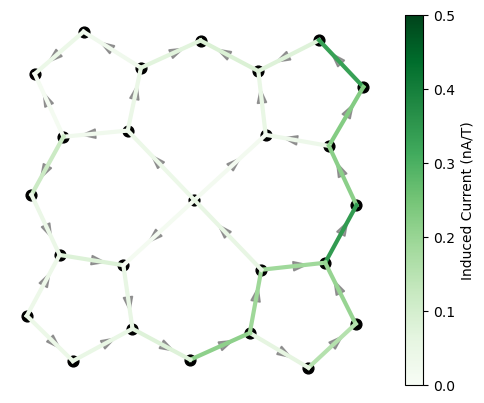

In [24]:
currents = get_currents("ATEWUT", session)
df = currents[(currents["height"] == 3) & (currents["width"] == 3)]
plot_currents(plt.gca(), MACROCYCLE_POINTS, df[["begin", "end", "value"]].to_dict(orient='records'))

In [2]:
xyz_path = "../data/nmr/ATUSOX_0_out/gimic/mol.xyz"
mol = utils.get_molecule(xyz_path)
mol.DeleteHydrogens()

True

In [3]:
jvec_vti_file = "../data/nmr/ATUSOX_0_out/gimic/jvec.vti"
vtk_data = gutils.read_vti_file(jvec_vti_file)

In [4]:
# Extract all metadata from vtk_data
print(vtk_data.GetInformation())


vtkInformation (0x55f2a9049f70)
  Debug: Off
  Modified Time: 361
  Reference Count: 2
  Registered Events: (none)
  DATA_NUMBER_OF_GHOST_LEVELS: 0
  DATA_NUMBER_OF_PIECES: 1
  DATA_PIECE_NUMBER: 0
  DATA_EXTENT: 0 300 0 283 0 186
  DATA_EXTENT_TYPE: 1




In [7]:
while True:
    for atom in ob.OBMolAtomIter(mol):
        if atom.GetAtomicNum() == 1:
            mol.DeleteAtom(atom)
            break
    else:
        break
    
mol.ConnectTheDots()
porphyrin_atoms = list(find_structure_indices(mol, "porphyrins")[0].keys())
metal_idx = None
for atom_idx in porphyrin_atoms:
    atom = mol.GetAtom(atom_idx)
    if atom.GetAtomicNum() != 7:
        continue
    for nbr in ob.OBAtomAtomIter(atom):
        nbr_idx = nbr.GetIdx()
        if nbr_idx not in porphyrin_atoms and nbr.GetAtomicNum() != 7:
            metal_idx = nbr_idx
porphyrin_atoms.append(metal_idx)



In [8]:
def calculate_flux_through_bond(bond: ob.OBBond, vti_data: vtk.vtkImageData, surface_width: float, surface_height: float):
    """
    Calculates the flux of a vector field through a bond.

    Args:
        bond (ob.OBBond): An OpenBabel bond object.
        vti_file (str): Path to the .vti file containing the vector field.
        bond_radius (flat): Radius of bond to calcualte flux

    Returns:
        float: The flux of the vector field through the bond.
    """
    # extract the vector function
    vector_function = gutils.get_vector_function(vti_data)

    # Get the bond's start and end points
    atom1 = bond.GetBeginAtom()
    atom2 = bond.GetEndAtom()
    start = np.array([atom1.GetX(), atom1.GetY(), atom1.GetZ()])
    end = np.array([atom2.GetX(), atom2.GetY(), atom2.GetZ()])

    # Calculate the bond's center and direction
    center = (start + end) / 2
    direction = end - start
    normal = direction / np.linalg.norm(direction)

    # Calculate the flux through the bond
    return gutils.calculate_flux_through_plane_adaptive(vector_function, center, surface_width, surface_height, normal, N=10)

In [9]:
def calculate_bond_integrals(width, height, data):
    # print("Calculating with radius", bond_radius)
    bond_integrals = {}
    for atom_idx in porphyrin_atoms:
        atom_obj = mol.GetAtom(atom_idx)
        for nbr in ob.OBAtomAtomIter(atom_obj):
            nbr_idx = nbr.GetIdx()
            if nbr_idx in porphyrin_atoms and atom_idx < nbr_idx:
                bond = mol.GetBond(atom_obj.GetIdx(), nbr.GetIdx())
                integral = calculate_flux_through_bond(
                    bond, data, width, height
                )
                bond_integrals[(bond.GetBeginAtomIdx(), bond.GetEndAtomIdx())] = integral
    return bond_integrals

# Calculate bond integrals for bond_radius = 1, 2, 3, 4
widths = [1, 1.5, 2, 2.5, 3]
heights = [1, 1.5, 2, 2.5, 3]
ajr = []
for w in widths:
    for h in heights:
        print("running with w={}, h={}".format(w, h))
        ints = calculate_bond_integrals(w, h, vtk_data)
        ajr.extend([{"width": w, "height": h, "bond": k, "flux": v} for k, v in ints.items()])


# Create DataFrame with (atom1, atom2) as index and columns for each radius
df_bond_integrals = pd.DataFrame(ajr)
df_bond_integrals


running with w=1, h=1
running with w=1, h=1.5
running with w=1, h=2
running with w=1, h=2.5
running with w=1, h=3
running with w=1.5, h=1
running with w=1.5, h=1.5
running with w=1.5, h=2
running with w=1.5, h=2.5
running with w=1.5, h=3
running with w=2, h=1
running with w=2, h=1.5
running with w=2, h=2
running with w=2, h=2.5
running with w=2, h=3
running with w=2.5, h=1
running with w=2.5, h=1.5
running with w=2.5, h=2
running with w=2.5, h=2.5
running with w=2.5, h=3
running with w=3, h=1
running with w=3, h=1.5
running with w=3, h=2
running with w=3, h=2.5
running with w=3, h=3


,width,height,bond,flux
0,1.0,1.0,"(6, 5)",-0.142616
1,1.0,1.0,"(7, 6)",-0.067440
2,1.0,1.0,"(8, 7)",0.018448
3,1.0,1.0,"(20, 7)",-0.062177
4,1.0,1.0,"(23, 8)",0.019526
...,...,...,...,...
795,3.0,3.0,"(4, 3)",0.016853
796,3.0,3.0,"(53, 1)",-0.043275
797,3.0,3.0,"(21, 1)",0.054021
798,3.0,3.0,"(1, 19)",-0.106969


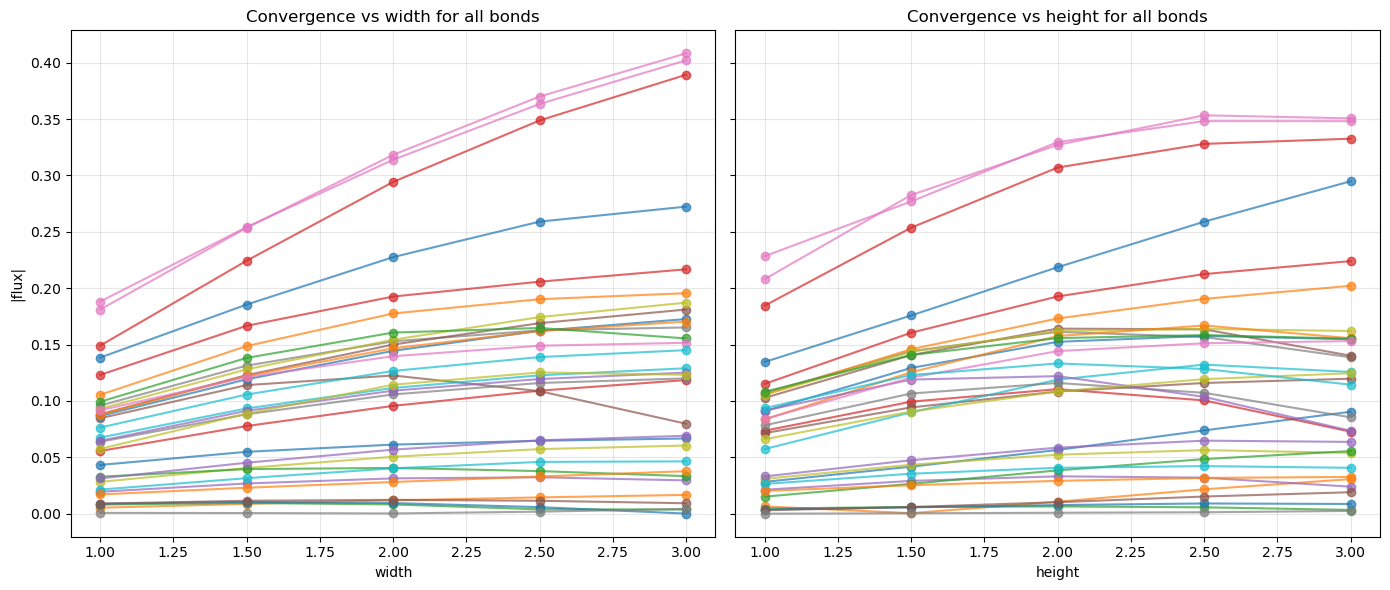

In [11]:
# Plot |flux| vs width and vs height for all bonds in the same plot

# Pivot the dataframe for easier plotting
pivot_w = df_bond_integrals.pivot_table(index="width", columns="bond", values="flux", aggfunc="mean")
pivot_h = df_bond_integrals.pivot_table(index="height", columns="bond", values="flux", aggfunc="mean")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# |flux| vs width for each bond (one line per bond)
for bond in pivot_w.columns:
    axes[0].plot(pivot_w.index, pivot_w[bond].abs(), marker='o', label=str(bond), alpha=0.7)
axes[0].set_xlabel('width')
axes[0].set_ylabel('|flux|')
axes[0].set_title('Convergence vs width for all bonds')
axes[0].grid(True, alpha=0.3)

# |flux| vs height for each bond (one line per bond)
for bond in pivot_h.columns:
    axes[1].plot(pivot_h.index, pivot_h[bond].abs(), marker='o', label=str(bond), alpha=0.7)
axes[1].set_xlabel('height')
axes[1].set_title('Convergence vs height for all bonds')
axes[1].grid(True, alpha=0.3)

# Optionally, show legend for a subset of bonds to avoid clutter
handles, labels = axes[1].get_legend_handles_labels()
# if len(labels) > 15:
#     axes[1].legend(handles[:15], labels[:15], title='bond (showing 15)', fontsize=8)
# else:
#     axes[1].legend(title='bond', fontsize=8)

plt.tight_layout()
plt.show()
